In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Spectra


### From Paper https://arxiv.org/pdf/0802.3566

In [5]:
data_black_curve = np.loadtxt('/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Dataset 0(2).csv', delimiter=',', skiprows=1)

In [6]:
year = 365 * 24 * 3600  # seconds in a year

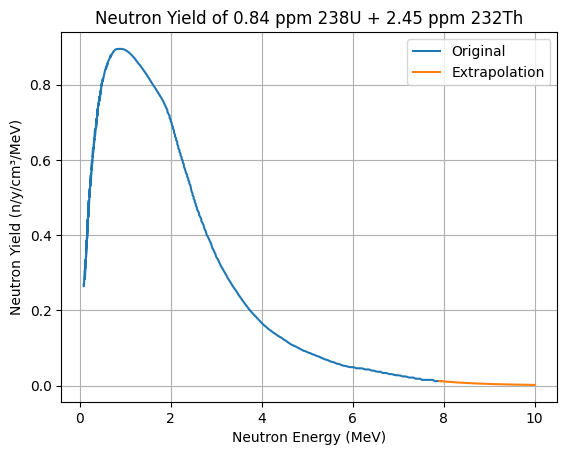

In [25]:
x = data_black_curve[:, 0]
y = data_black_curve[:, 1] * 1e-8 * year

mask = x > 7.6
x_tail = x[mask]
y_tail = y[mask]

def expo(x, A, k):
    return A * np.exp(-k * x)

popt, pcov = curve_fit(expo, x_tail, y_tail, p0=(y_tail.max(), 0.5))
A_fit, k_fit = popt

# 4. Extrapolation bis 10 MeV
x_ext = np.linspace(7.9, 10.0, 200)
y_ext = expo(x_ext, A_fit, k_fit)

# 5. Plot zum Vergleich
plt.title('Neutron Yield of 0.84 ppm 238U + 2.45 ppm 232Th')
plt.plot(x, y,   label='Original')
plt.plot(x_ext, y_ext,  label='Extrapolation')
plt.xlabel('Neutron Energy (MeV)')
plt.ylabel('Neutron Yield (n/y/cm³/MeV)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
x_full = np.concatenate((x, x_ext))
y_full = np.concatenate((y, y_ext))

norm_y = y_full / sum(y_full)

data = np.column_stack((x_full, norm_y))

# data nach x sortieren
data = data[np.argsort(data[:, 0])]
np.savetxt('RadiogenicNeutronDistribution.txt', data, delimiter=' ', header="unit: MeV \nspectrum:", comments='')

### Analytic

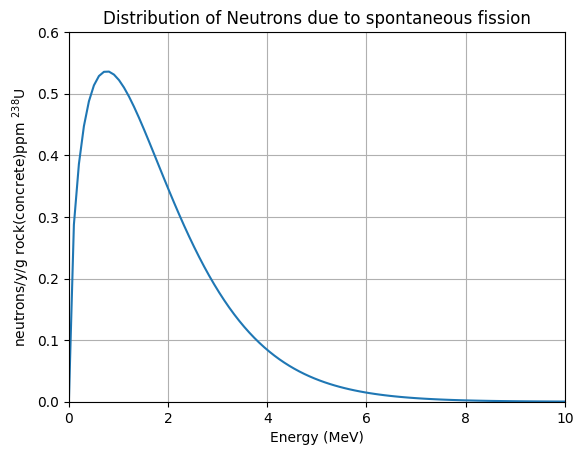

0.5358951308737832
0.13607922570793352


In [3]:
def disEventsFission(E):
    a = 0.7124 # MeV
    b = 5.6405 # MeV**-1
    C = 0.218 / (np.exp(-1/a) * np.sinh((b*1)**(1/2))) # MeV**-1
    y = C * np.exp(-E/a) * np.sinh((b*E)**(1/2) )
    return y

# Average number of neutrons emitted per fission event
R = 2.4 # +- 0.2

x = np.linspace(0, 10, 100)
y = disEventsFission(x) * R 
plt.plot(x, y)

plt.title('Distribution of Neutrons due to spontaneous fission')
plt.xlabel('Energy (MeV)')
plt.ylabel(r'neutrons/y/g rock(concrete)ppm $^{238}$U')
plt.xlim(0, 10)
plt.ylim(0, 0.6)
plt.grid()

plt.show()

print(np.max(y))
print(np.mean(y))


In [5]:
y_norm = y / np.sum(y) # Normalize the distribution 

data = np.column_stack((x, y_norm))
np.savetxt('ThermicNeutronsDistributions.txt', data, delimiter=' ', header="unit: MeV \nspectrum:", comments='')

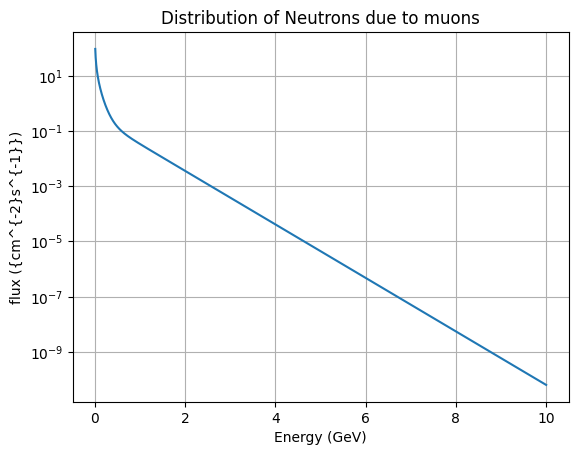

0.08261504678644335


In [ ]:
def disNeutronsMuonen(E):
    Eu = 270 # GeV
    a0 = 7.828
    a1 = 2.23
    a2 = -7.505 * 10**(-15)
    a3 = 2.831
    A = 1

    Bu = 0.324 - 0.641*np.exp(-0.014*Eu)

    y = A * (np.exp(-a0 * E)/E + Bu * np.exp(-a1*E)) + a2 * E**(-a3) 
    return y
    
x = np.linspace(0.01, 10, 100000)
y = disNeutronsMuonen(x)
plt.plot(x, y)

plt.title('Distribution of Neutrons due to muons')
plt.xlabel('Energy (GeV)')
plt.ylabel(r'flux ({cm^{-2}s^{-1}})')
plt.yscale('log')
#plt.xlim(0, 4)
#plt.ylim(0, 10**(-8))
plt.grid()

plt.show()

average_energy = np.trapezoid(x * y, x) / np.trapezoid(y, x)

print(average_energy)

#Rock stats used
# density = 2.65 g/cm^3
# A = 22
# Z = 11

In [3]:
data = np.column_stack((x, y))
np.savetxt('CosmicNeutronsDistributions.txt', data, delimiter=' ', header="unit: GeV \nspectrum:", comments='')

NameError: name 'x' is not defined

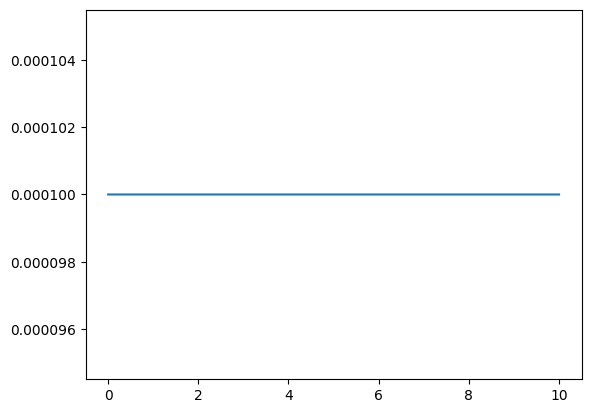

In [2]:
x = np.linspace(0.001, 10.001, 10000)
y = np.ones(10000)/10000

data = np.column_stack((x, y))

plt.plot(x, y)

np.savetxt('ConstantDistribution.txt', data, delimiter=' ', header="unit: MeV \nspectrum:", comments='')


# Calculations of fractions


In [ ]:
f_H_m = 9.3/100
f_eB_m = 25/100
f_C_m = 1 - f_H_m - f_eB_m

f_B10 = 19.6/100
f_B11 = 80.4/100


f_B10_m = f_B10 * f_eB_m
f_B11_m = f_B11 * f_eB_m

In [ ]:
M_H = 1.00794 # g/mol
M_B10 = 10.012937 # g/mol
M_B11 = 11.009305 # g/mol
M_C = 12.0107 # g/mol

M_eB = f_B10 * M_B10 + f_B11 * M_B11


In [ ]:
f_H = (f_H_m / M_H) / (f_H_m / M_H + f_eB_m / M_eB + f_C_m / M_C)
f_eB = (f_eB_m / M_eB) / (f_H_m / M_H + f_eB_m / M_eB + f_C_m / M_C)
f_C = (f_C_m / M_C) / (f_H_m / M_H + f_eB_m / M_eB + f_C_m / M_C)
print(f'H: {f_H:.4f}, eB: {f_eB:.4f}, C: {f_C:.4f}')


H: 0.5425, eB: 0.1359, C: 0.3216


In [ ]:
f_H_m = 9.3/100
f_eB_m = 25/100
f_C_m = 1 - f_H_m - f_eB_m

f_B10 = 19.6/100
f_B11 = 80.4/100


f_B10_m = f_B10 * f_eB_m
f_B11_m = f_B11 * f_eB_m

In [ ]:
M_H = 1.00794 # g/mol
M_B10 = 10.012937 # g/mol
M_B11 = 11.009305 # g/mol
M_C = 12.0107 # g/mol

M_eB = f_B10 * M_B10 + f_B11 * M_B11


In [ ]:
f_H = (f_H_m / M_H) / (f_H_m / M_H + f_eB_m / M_eB + f_C_m / M_C)
f_eB = (f_eB_m / M_eB) / (f_H_m / M_H + f_eB_m / M_eB + f_C_m / M_C)
f_C = (f_C_m / M_C) / (f_H_m / M_H + f_eB_m / M_eB + f_C_m / M_C)
print(f'H: {f_H:.4f}, eB: {f_eB:.4f}, C: {f_C:.4f}')


H: 0.5425, eB: 0.1359, C: 0.3216
